# SLM phase-calibration workflow

This notebook uses the existing live camera viewer to identify diffraction-order positions while keeping acquisition, persistence, and plotting in reusable Python functions.

Workflow:

1. Configure and connect to the camera and SLM.
2. Display a binary grating and locate the 0th, +1st, and -1st diffraction orders.
3. Enter and confirm the camera coordinates.
4. Acquire the grey-level sweep and immediately save the raw measurements with metadata.
5. Adjust the fit parameters until the measured and fitted curves agree.
6. Explicitly approve LUT generation, loading, and validation.
7. Repeat steps 4 through 6 until a sufficiently linear LUT is obtained. For each iteration, use the newly generated LUT as `BASE_LUT_FILE` and choose a new `NEW_LUT_PREFIX`.



## Before starting: Start the hardware servers

Start the camera server, SLM server, and live camera viewer in separate terminals before running the connection cells. The viewer is used in step 4 to read the diffraction-order positions.

In [53]:
%matplotlib inline

from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import JazLabs.hardware.Cameras.Camera_Client as CameraClientLib
import JazLabs.hardware.SLM.PhaseMaskClass as PhaseMaskClass
from JazLabs.hardware.SLM.SLMStack import SLMClient
import JazLabs.procedures.SLM.SLM_PhaseCalibration as PhaseCalibration
import JazLabs.procedures.SLM.SLMPhaseCalibrationFunctions as PhaseAnalysis

%load_ext autoreload
%aimport JazLabs.procedures.SLM.SLM_PhaseCalibration
%aimport JazLabs.procedures.SLM.SLMPhaseCalibrationFunctions
%autoreload 1

plt.style.use("dark_background")

from pathlib import Path
import JazLabs
JAZLABS_ROOT = Path(JazLabs.__file__).resolve().parents[2]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Configure and connect to the camera and SLM

The next two cells contain the camera and SLM connection settings. Check the host, ports, SLM channel, polarisation, centre-alignment filename, and initial LUT before running them. Existing clients are closed first so the cells can be rerun safely.

### Camera and SLM clients

The first cell connects to the camera. The second connects to the SLM, constructs the phase-mask object, loads the saved mask centres, and loads `INITIAL_LUT_FILE` as the starting calibration.

In [54]:
# Hardware connections.
SERVER_HOST = "127.0.0.1"
CAMERA_COMMAND_PORT = 50733
CAMERA_FRAME_PORT = 50734


try:
    camera_client.close()
except NameError:
    pass

camera_client = CameraClientLib.CameraClient(
    host=SERVER_HOST,
    command_port=CAMERA_COMMAND_PORT,
    frame_pub_port=CAMERA_FRAME_PORT,
    timeout_ms=60000,
    client_id="slm_phase_calibration_notebook",
)
camera_properties = camera_client.GetProperties()

In [55]:
SLM_COMMAND_PORT = 5555
SLM_DISPLAY_PORT = 5556

# SLM and mask settings.
CHANNEL = "Red"
POLARISATION = "H"
MASK_INDEX = 0
MASK_PROPERTIES_FILENAME = "SLM_CenterAlignment.npy"
SLM_PIXEL_SIZE = 17e-6
SLM_WAVELENGTH = 1550e-9

#LUT to be loaded at begin of calibration
LUTFOLDER =JAZLABS_ROOT/ "calibrations"/ "SLM"/ "CustomLutFiles"
INITIAL_LUT_FILE =  "1024x1024_linearVoltage.lut"

try:
    slm_client.close()
except NameError:
    pass

slm_client = SLMClient(
    host=SERVER_HOST,
    command_port=SLM_COMMAND_PORT,
    display_pub_port=SLM_DISPLAY_PORT,
    timeout_ms=5000,
    attach_viewer_shared_memory=False,
)
phase_mask = PhaseMaskClass.PhaseMaskObject(
    SLMObject=slm_client,
    ActiveRGBChannels=[CHANNEL],
    pixel_size=SLM_PIXEL_SIZE,
    wavelength=SLM_WAVELENGTH,
)
phase_mask.polProps[CHANNEL]["V"].polEnabled = False
phase_mask.LoadMaskProperties(
    filenamePrefix=MASK_PROPERTIES_FILENAME,
    PolSelector=POLARISATION,
)
slm_client.LoadLutFile(str(LUTFOLDER / INITIAL_LUT_FILE))


        Zern Coefs:
        0:  piston    ( 0,  0 )
        1:  Tiltx     (1,  -1 )
        2:  Tilty     ( 1,  1 )
        3:  Astigx    (2,  -2 )
        4:  Defocus   ( 2,  0 )
        5:  Astigy    ( 2,  2 )
        6:  Trefilx   (3,  -3 )
        7:  Comax     (3,  -1 )
        8:  Comay     ( 1,  3 )
        9:  Trefoily  ( 3,  3 )
        12:  Spherical ( 4,  0 )
        
1024
1024
[  1   1 256 256]
Cleaning up resources...
Destroying


1

## 2. Locate the diffraction orders in the live camera viewer

Use the next two cells while watching the separate live camera viewer:

1. Run the blank-SLM cell and record the zeroth-order position.
2. Run the binary-grating cell and record the +1 and -1 order positions.
3. Enter the three positions in the coordinate cell in step 3.

The viewer normally reports `(x, y)`. Enter each centre in the next coordinate cell as `[row, column]`, which is `[y, x]`.

In [5]:
phase_mask.Clear_Display(CHANNEL)
print("The SLM is blank. Read the zeroth-order (x, y) position from the live camera viewer.")

The SLM is blank. Read the zeroth-order (x, y) position from the live camera viewer.


In [56]:
# Binary diffraction grating and acquisition.
GRATING_DIRECTION = "y"
STRIPE_WIDTH = 25
DIAGNOSTIC_GREY_LEVEL = 128
BACKGROUND_LEVEL = 0
PhaseCalibration.DisplayBinaryDiffractionPattern(
    phase_mask,
    CHANNEL,
    Direction=GRATING_DIRECTION,
    strip_width=STRIPE_WIDTH,
    strip_value=DIAGNOSTIC_GREY_LEVEL,
)
print("The binary grating is displayed. Read the +1 and -1 (x, y) positions from the live camera viewer.")

The binary grating is displayed. Read the +1 and -1 (x, y) positions from the live camera viewer.


## 3. Confirm the camera coordinates

Enter the viewer positions in the next code cell, then run it to confirm the `[row, column]` values that will be used by the calibration scan.

In [57]:
# Read these positions from the live camera viewer.
# The aperture code expects [row, column], equivalent to viewer [y, x].
ZEROTH_ORDER_CENTER_ROW_COLUMN = [64, 64]
PLUS_FIRST_ORDER_CENTER_ROW_COLUMN = [64, 100]
MINUS_FIRST_ORDER_CENTER_ROW_COLUMN = [64, 27]
diffraction_order_centers = {
    "0th": list(ZEROTH_ORDER_CENTER_ROW_COLUMN),
    "+1st": list(PLUS_FIRST_ORDER_CENTER_ROW_COLUMN),
    "-1st": list(MINUS_FIRST_ORDER_CENTER_ROW_COLUMN),
}

print("Camera centres used by the scan [row, column]:")
for order_label, center_row_column in diffraction_order_centers.items():
    print(f"  {order_label}: {center_row_column}")

Camera centres used by the scan [row, column]:
  0th: [64, 64]
  +1st: [64, 100]
  -1st: [64, 27]


## 4. Acquire or load the raw calibration

Set `ACQUIRE_NEW_DATA = True` only after confirming the three camera coordinates. The acquisition scans grey levels from 0 to 255 in order, averages the requested number of frames, records a cleared-SLM reference in the final array entry, and restores the camera and SLM afterward. Raw measurements are saved immediately with their acquisition metadata.

In [ ]:

# Raw calibration data.
RAW_DATA_FILE = LUTFOLDER / "PowerPhaseCalibration.npz"
ACQUIRE_NEW_DATA = True

CAMERA_FRAME_AVERAGES = 1
APERTURE_HALF_WIDTH_X = 10
APERTURE_HALF_WIDTH_Y = 10
if ACQUIRE_NEW_DATA:
    zero_order_power, plus_first_power, minus_first_power = (
        PhaseCalibration.PhaseCalibration_BinaryDiffraction_Cam_0thAnd1stOrder(
            slm=phase_mask,
            Cam=camera_client,
            channel=CHANNEL,
            Direction=GRATING_DIRECTION,
            imask=MASK_INDEX,
            pol=POLARISATION,
            backgroundLevel=BACKGROUND_LEVEL,
            strip_width=STRIPE_WIDTH,
            camframeAvg=CAMERA_FRAME_AVERAGES,
            ixCamCenter0th=diffraction_order_centers["0th"][0],
            iyCamCenter0th=diffraction_order_centers["0th"][1],
            ixCamCenter_plus1st=diffraction_order_centers["+1st"][0],
            iyCamCenter_plus1st=diffraction_order_centers["+1st"][1],
            ixCamCenter_minus1st=diffraction_order_centers["-1st"][0],
            iyCamCenter_minus1st=diffraction_order_centers["-1st"][1],
            x_half_width=APERTURE_HALF_WIDTH_X,
            y_half_width=APERTURE_HALF_WIDTH_Y,
            phaseLevels=256,
            Verbose=True,
        )
    )

    acquisition_metadata = {
        "acquired_at": datetime.now().astimezone().isoformat(),
        "channel": CHANNEL,
        "polarisation": POLARISATION,
        "mask_index": MASK_INDEX,
        "slm_wavelength_m": SLM_WAVELENGTH,
        "slm_pixel_size_m": SLM_PIXEL_SIZE,
        "grating_direction": GRATING_DIRECTION,
        "stripe_width_px": STRIPE_WIDTH,
        "camera_frame_averages": CAMERA_FRAME_AVERAGES,
        "aperture_half_width_x_px": APERTURE_HALF_WIDTH_X,
        "aperture_half_width_y_px": APERTURE_HALF_WIDTH_Y,
        "diffraction_order_centers": diffraction_order_centers,
    }
    saved_path = PhaseCalibration.SavePhaseCalibrationMeasurements(
        str(RAW_DATA_FILE),
        zero_order_power,
        plus_first_power,
        minus_first_power,
        metadata=acquisition_metadata,
    )
    print(f"Saved raw calibration to {saved_path}")
else:
    measurements, acquisition_metadata = (
        PhaseCalibration.LoadPhaseCalibrationMeasurements(str(RAW_DATA_FILE))
    )
    zero_order_power = measurements["PowerValues_0th"]
    plus_first_power = measurements["PowerValues_plus1st"]
    minus_first_power = measurements["PowerValues_minus1st"]
    print(f"Loaded raw calibration from {RAW_DATA_FILE}")

acquisition_metadata

PhaseCalibration.PlotPhaseCalibrationMeasurements(
    zero_order_power,
    plus_first_power,
    minus_first_power,
    include_reference=False,
)

Acquiring grey level 0/255
Acquiring grey level 16/255
Acquiring grey level 32/255
Acquiring grey level 48/255
Acquiring grey level 64/255
Acquiring grey level 80/255
Acquiring grey level 96/255
Acquiring grey level 112/255
Acquiring grey level 128/255
Acquiring grey level 144/255
Acquiring grey level 160/255
Acquiring grey level 176/255
Acquiring grey level 192/255
Acquiring grey level 208/255
Acquiring grey level 224/255
Acquiring grey level 240/255
Acquiring grey level 255/255
Saved raw calibration to C:\Users\sail\Documents\DansWorkDontTouch\HDStokes\JazLabs\calibrations\SLM\CustomLutFiles\PowerPhaseCalibration_4.npz


{'acquired_at': '2026-07-30T12:37:30.549337+10:00',
 'channel': 'Red',
 'polarisation': 'H',
 'mask_index': 0,
 'slm_wavelength_m': 1.55e-06,
 'slm_pixel_size_m': 1.7e-05,
 'grating_direction': 'y',
 'stripe_width_px': 25,
 'camera_frame_averages': 1,
 'aperture_half_width_x_px': 10,
 'aperture_half_width_y_px': 10,
 'diffraction_order_centers': {'0th': [64, 64],
  '+1st': [64, 100],
  '-1st': [64, 27]}}

## 5. Fit and inspect the phase response

This is the main iterative stage. Adjust the `FIT_*` values at the top of the next cell and rerun that cell until the measured and fitted curves agree. Check that both power curves are represented and that the recovered phase is smooth, monotonic, and physically plausible. Do not run the LUT-generation cell until the fit is accepted.

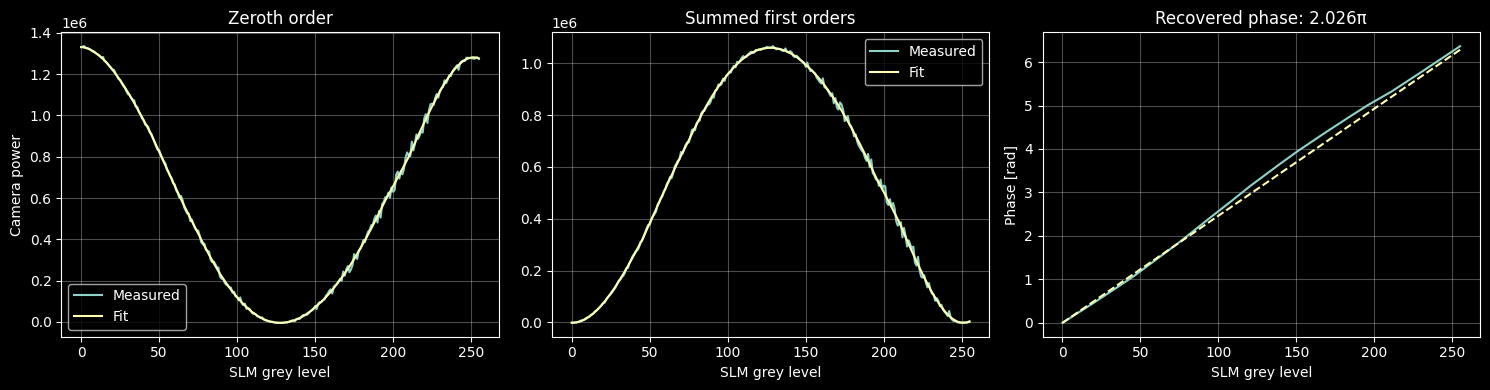

Recovered phase stroke: 2.0262π
Fit success: True
Fit message: `ftol` termination condition is satisfied.


In [62]:
# Fit parameters. Change these and rerun only the fit cell.
FIT_N_KNOTS = 18
FIT_POLYNOMIAL_DEGREE = 2
FIT_PHASE_MAX_GUESS = 2* np.pi
FIT_CURVATURE_PENALTY = 0.1
FIT_ROBUST = False
grey_levels = np.arange(zero_order_power.size - 1)
phase_fit = PhaseAnalysis.fit_slm_phase_I0_Ipm1(
    grey_levels,
    zero_order_power[:-1],
    plus_first_power[:-1],
    minus_first_power[:-1],
    n_knots=FIT_N_KNOTS,
    poly_deg=FIT_POLYNOMIAL_DEGREE,
    phi_max_guess=FIT_PHASE_MAX_GUESS,
    lam_curv=FIT_CURVATURE_PENALTY,
    robust=FIT_ROBUST,
)
PhaseCalibration.PlotPhaseCalibrationFit(
    phase_fit,
    zero_order_power,
    plus_first_power,
    minus_first_power,
)
print(f"Recovered phase stroke: {phase_fit['phi_end'] / np.pi:.4f}π")
print(f"Fit success: {phase_fit['scipy_result'].success}")
print(f"Fit message: {phase_fit['scipy_result'].message}")

## 6a. Generate the LUT after accepting the fit

Review and accept the fit plots before running the next cell: it generates the LUT immediately. Set `BASE_LUT_FILE` to the LUT used during the acquisition, choose a new and unused `NEW_LUT_PREFIX`, and check `PHASE_STROKE` and `PHASE_OFFSET`. The new `.lut` and `.blt` files are written using that prefix.

Hi 256
Total phase stroke(Max Phase - Min Phase) = 2.010 pi (6.315 rad)

Max Phase Shift Allowed ( (Max Phase - Min Phase)-2pi) = (0.032 rad)

Number of points after Max= 1
739


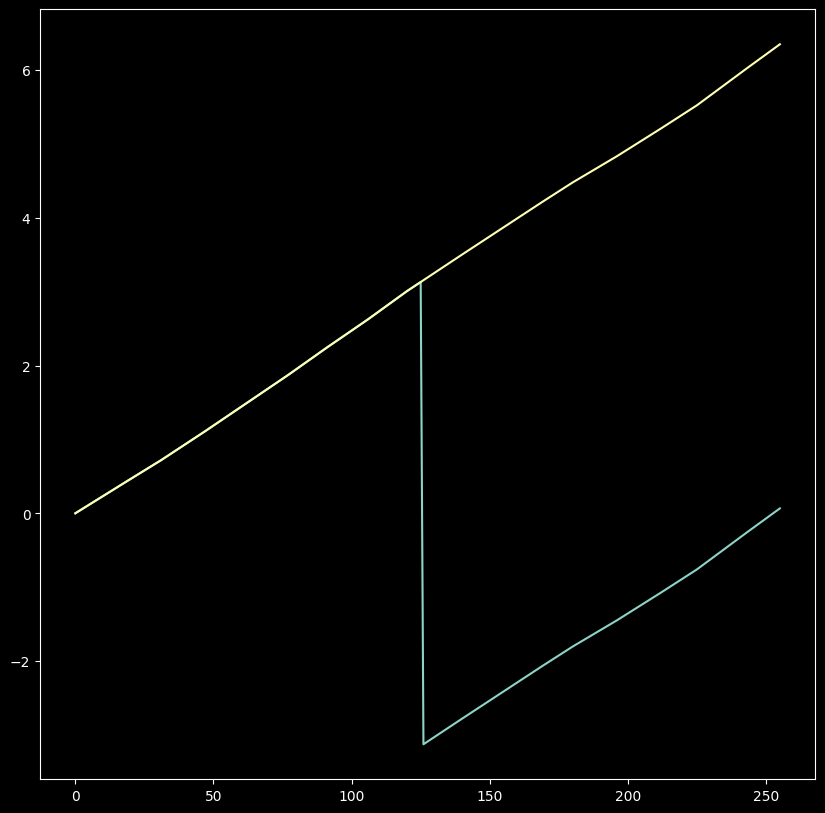

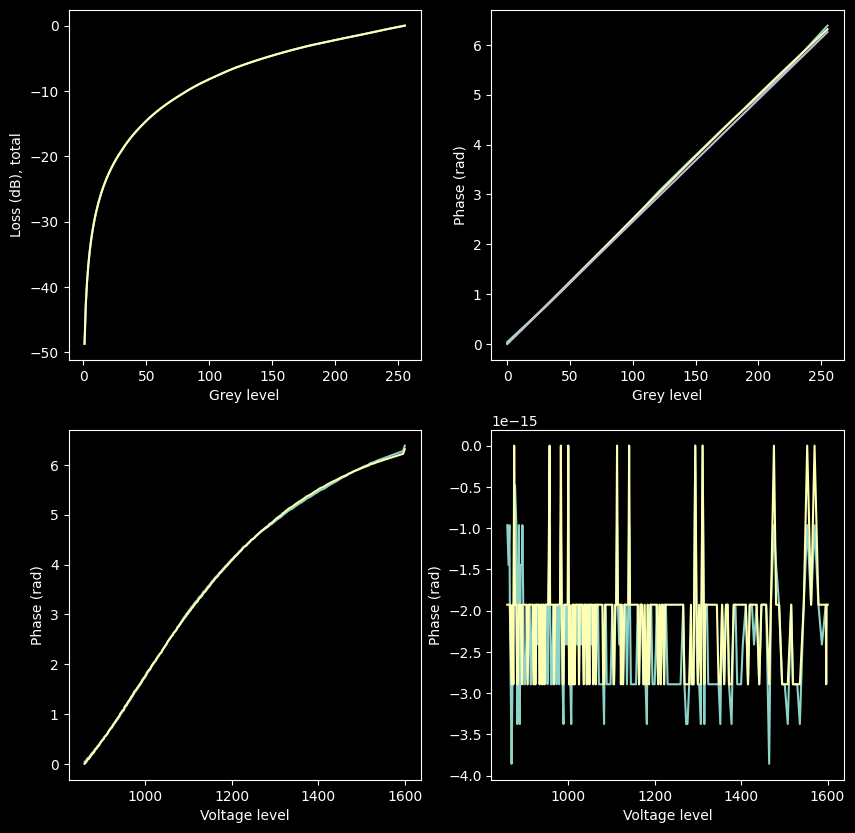

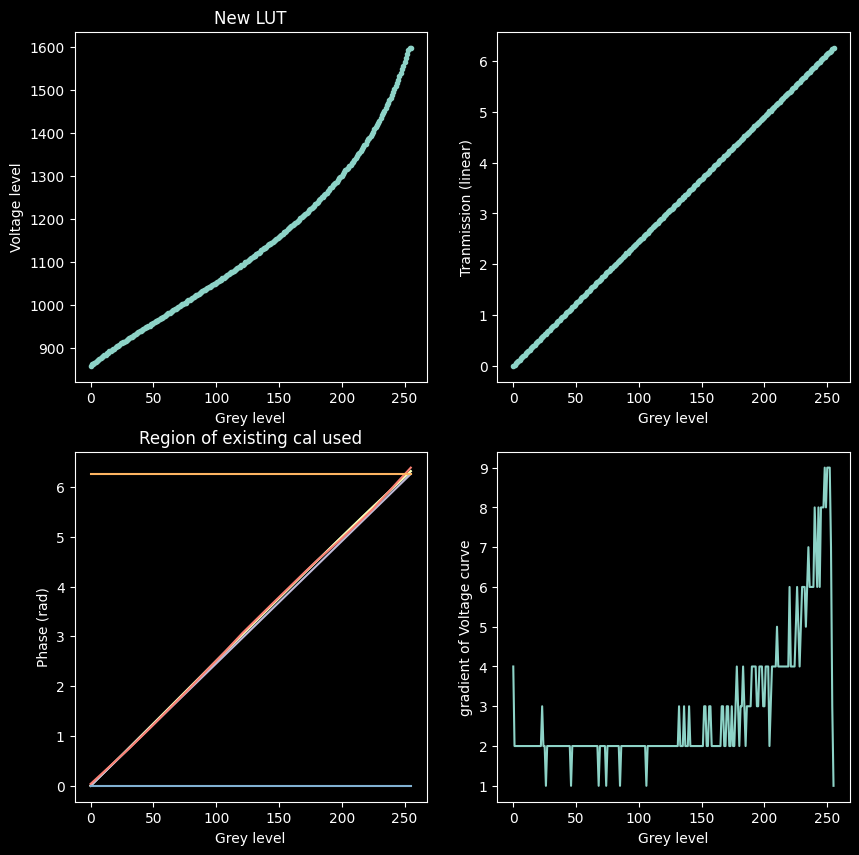

minGradVolt should be great then or equal to one. minGradVolt= 1.0 AvgGradVolt= 2.87890625
minGradPhase should not be less or equal to zero then zero. minGradPhase= 0.02083555590923236 AvgGradPhase= 0.02459141662325972 StdGradPhase= 0.0018994253337619928
Generated C:\Users\sail\Documents\DansWorkDontTouch\HDStokes\JazLabs\calibrations\SLM\CustomLutFiles\SLM_PhaseCalibration_New_4.lut and C:\Users\sail\Documents\DansWorkDontTouch\HDStokes\JazLabs\calibrations\SLM\CustomLutFiles\SLM_PhaseCalibration_New_4.blt


In [ ]:
# LUT generation is deliberately gated by two switches.
BASE_LUT_FILE = LUTFOLDER / "1024x1024_linearVoltage.lut"
# BASE_LUT_FILE = LUTFOLDER / "SLM_PhaseCalibration_New_3.lut"


NEW_LUT_PREFIX = LUTFOLDER / "SLM_PhaseCalibration_New_1"
PHASE_STROKE = 2.0* np.pi
PHASE_OFFSET = 0

NEW_LUT_PREFIX.parent.mkdir(parents=True, exist_ok=True)
recovered_phase = phase_fit["phi"]
phase_count = recovered_phase.size
overlap_signal_reference = np.exp(1j * recovered_phase)
overlap_reference_reference = recovered_phase
overlap_signal_signal = recovered_phase

lut_results = PhaseAnalysis.CalculatePhaseAndVoltageLevels(
    True,
    str(BASE_LUT_FILE),
    str(NEW_LUT_PREFIX),
    phase_count,
    PHASE_STROKE,
    PHASE_OFFSET,
    overlap_signal_reference,
    overlap_reference_reference,
    overlap_signal_signal,
)
print(f"Generated {NEW_LUT_PREFIX}.lut and {NEW_LUT_PREFIX}.blt")

## 6b. Load and validate the accepted LUT

If the SLM server runs on another computer, first copy the generated LUT to that computer. Set `WINDOWS_INSTALLED_LUT_FILE` to a path that is visible to the SLM server, then run the next cell to load it immediately.

Validate the loaded LUT by returning to step 6, acquiring a new raw sweep under a new filename, and rerunning the fit. A good calibration produces a recovered phase that is close to the linear-phase reference. If it is not sufficiently linear, use the newly generated LUT as the next `BASE_LUT_FILE`, choose a new `NEW_LUT_PREFIX`, and repeat steps 6 through 9.

In [ ]:

# Copy the generated LUT to Windows separately before enabling this.
WINDOWS_INSTALLED_LUT_FILE = LUTFOLDER / "SLM_PhaseCalibration_New_1.lut"
slm_client.LoadLutFile(str(WINDOWS_INSTALLED_LUT_FILE))
print(f"Loaded LUT: {WINDOWS_INSTALLED_LUT_FILE}")


Loaded LUT: C:\Users\sail\Documents\DansWorkDontTouch\HDStokes\JazLabs\calibrations\SLM\CustomLutFiles\SLM_PhaseCalibration_New_3.lut


## Finish: Disconnect

Clear the SLM and close both clients when calibration work is complete.

In [ ]:
phase_mask.Clear_Display(CHANNEL)
camera_client.close()
slm_client.close()